# Classical Decomposition of Time Series Data

- In Classicial Decomposition, Seasonal Components are shown as static repetative patterns.
- Flexibility is low, outlier handling is poor.

In [6]:
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
import warnings
from helpers import *

warnings.filterwarnings("ignore")

In [7]:
stock_data = get_stock_data()
    
stock_data.info()

Loading Data From Local
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 499 entries, 2024-01-02 to 2025-12-26
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, AAPL)   499 non-null    float64
 1   (High, AAPL)    499 non-null    float64
 2   (Low, AAPL)     499 non-null    float64
 3   (Open, AAPL)    499 non-null    float64
 4   (Volume, AAPL)  499 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 23.4 KB


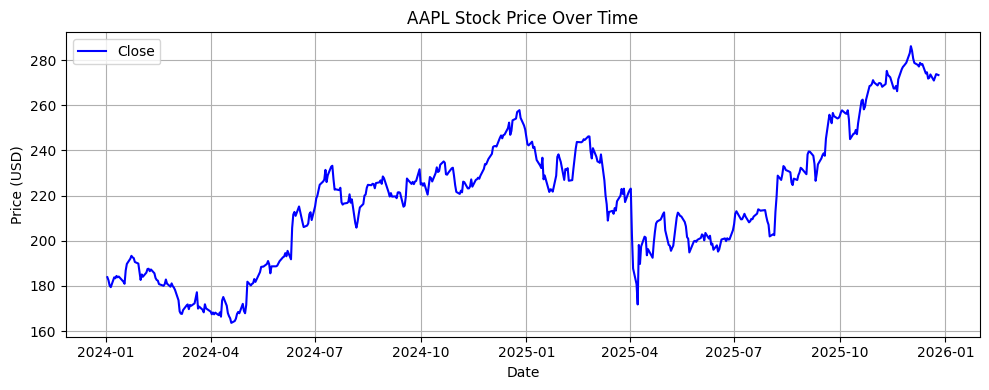

In [8]:
fig, ax = plt.subplots(figsize=(10, 4))

#ax.plot(stock_data.index, stock_data['Open'], label='Open', color='green')
#ax.plot(stock_data.index, stock_data['Low'], label='Low', color='black')
#ax.plot(stock_data.index, stock_data['High'], label='High', color='red')
ax.plot(stock_data.index, stock_data['Close'], label='Close', color='blue')
ax.set_title('AAPL Stock Price Over Time')
ax.set_xlabel('Date')
ax.set_ylabel('Price (USD)')
ax.legend()
ax.grid(True)

fig.tight_layout()
plt.show()

# Classical Time Series Decomposition

Time series models are commonly categorized into two types based on how their components combine:

**Additive Model**  
It is additive when the seasonal variations are constant (doesn't grow). It is used when seasonal variations are constant in magnitude, regardless of the level of the time series. Forexample Temperature Data, Seasonal Demands, Variance is constant over time.   

**Multiplicative Model**      
It is multiplicative if the seasonal variation grow as the series grow. It is used when seasonal variations scale with the level of the time series (i.e., proportional or percentage-based effects). Forexample, Revenue or Sales data, Stock prices, Website traffic, population growth.

![Model Types](./files/timeseries_categories.jpg)
  

# Components of a Time Series
  
A time series is typically composed of three fundamental components:

- **Trend (T)**  
  The long-term direction or movement in the data.  
- **Seasonality (S)**  
  Repeating predictable patterns over fixed period (daily, monthly, quarterly, yearly, etc).  
- **Residuals / Noise (R)**  
  Random fluctuations/noise not explained by trends or seasonality.  

![Decomposition](./files/time_series_decomposition.png)

# Decomposition Concept

Decomposition is the process of separating a time series into these three components.
Once decomposed, we can reconstruct (compose) the original time series using either an additive or multiplicative formulation, depending on the nature of the data.

## Additive Model  
$ Y_t = Trends_{(t)} + Seasonality_{(t)} + Residual_{(t)} $  
$ Y_t = T_t + S_t + R_t $  

## Multiplicative Model
$ Y_t = Trends_{(t)} \times Seasonality_{(t)} \times Residual_{(t)} $  
$ Y_t = T_t \times S_t \times R_t $  

A multiplicative model becomes additive after a log transformation:  
  
$ log(Y_t) = log(T_t) + log(S_t) + log(R_t) $  

In [9]:
additive_decomposition = seasonal_decompose(stock_data['Close'], model='additive', period=30)

add_trend = additive_decomposition.trend
add_seasonal = additive_decomposition.seasonal
add_residual = additive_decomposition.resid

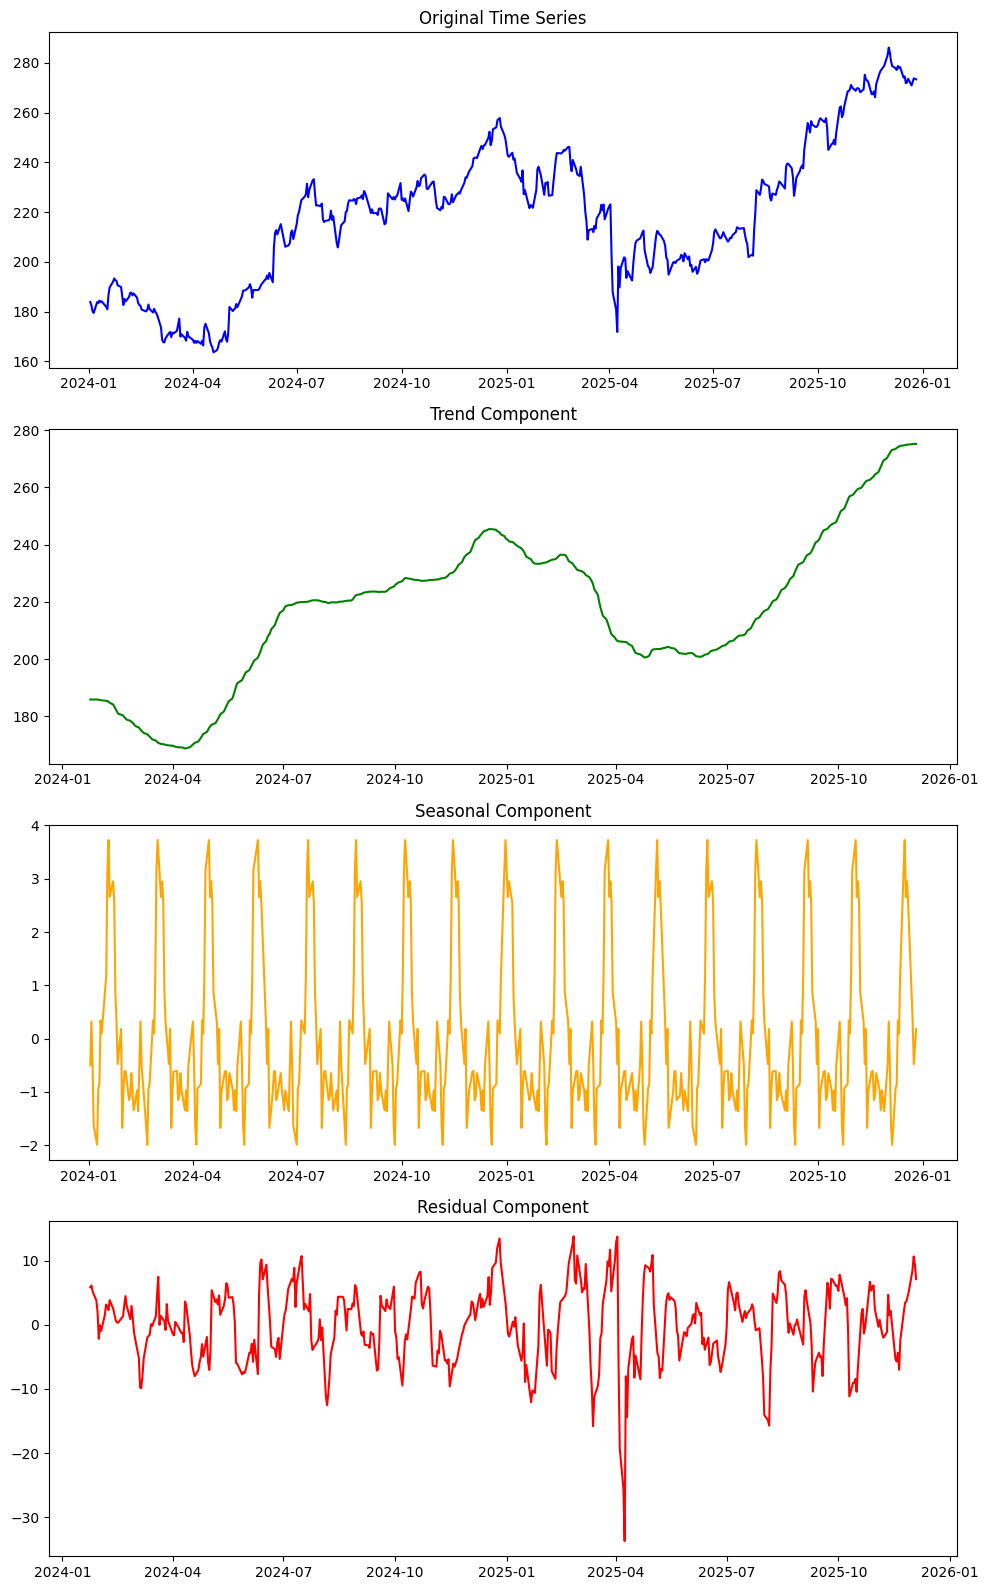

In [10]:
fig, axs = plt.subplots(4, 1, figsize=(10, 16))

# Actual
axs[0].plot(stock_data.index, stock_data['Close'], label='Original', color='blue')
axs[0].set_title("Original Time Series")
# Trend
axs[1].plot(add_trend, label='Trend', color='green')
axs[1].set_title("Trend Component")
# Seasonal
axs[2].plot(add_seasonal, label='Seasonal', color='orange')
axs[2].set_title("Seasonal Component")
# Residual
axs[3].plot(add_residual, label='Residual', color='red')
axs[3].set_title("Residual Component")

fig.tight_layout()
plt.show()